In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
import os

import sde_lib

from models import ddpm as ddpm_model
from models import utils as mutils
from configs.vp import AI4Scup2_ddpm_continuous as configs

from utils_cbs import plot2Dimage, RelL2Loss

# Setting Configs
config = configs.get_config()
config.device_ids = [1,2,3,4]
config.device = torch.device('cuda:' + str(config.device_ids[0])) if torch.cuda.is_available() else torch.device('cpu')

In [2]:
score_model_path = "/home/caoxiang/Desktop/diffusion_model/score_sde_pytorch_training/workdir/AI4Scup2/256/checkpoints/checkpoint_25.pth"

score_model = ddpm_model.DDPM(config)
score_model = torch.nn.DataParallel(score_model, config.device_ids)
score_model = score_model.cuda(device=config.device_ids[0])

# Resume training when intermediate checkpoints are detected; 
loaded_state = torch.load(score_model_path, map_location=config.device)
score_model.load_state_dict(loaded_state['model'], strict=False)

# Define the diffusion process SDE
sde = sde_lib.VPSDE(beta_min=config.model.beta_min, beta_max=config.model.beta_max, N=config.model.num_scales)
score_fn = mutils.get_score_fn(sde, score_model, train=False, continuous=config.training.continuous)
sampling_eps = 1e-4

In [3]:
from timm.models.swin_transformer import SwinTransformer

class UNetDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNetDecoderBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
    def forward(self, x):
        x = self.upsample(x)
        x = self.conv(x)
        return x

class SwinUNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=1, img_size=256, patch_size=4, embed_dim=128, depths=[2, 2, 18, 2], num_heads=[4, 8, 16, 32]):
        super(SwinUNet, self).__init__()
        
        # Swin Transformer 编码器
        self.swin = SwinTransformer(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_channels,
            embed_dim=embed_dim,
            depths=depths,
            num_heads=num_heads,
            window_size=8,
            mlp_ratio=4.,
            qkv_bias=True,
            drop_rate=0.1,
            attn_drop_rate=0.1,
            drop_path_rate=0.2,
            norm_layer=nn.LayerNorm,
            ape=False,
            patch_norm=True,
            use_checkpoint=False
        )
        
        # 解码器
        self.decoder5 = UNetDecoderBlock(1024, 512)
        self.decoder4 = UNetDecoderBlock(512, 256)
        self.decoder3 = UNetDecoderBlock(256, 128)
        self.decoder2 = UNetDecoderBlock(128, 64)
        self.decoder1 = UNetDecoderBlock(64, 32)
        
        # 输出层
        self.final_conv = nn.Conv2d(32, out_channels, kernel_size=1)
        
    def forward(self, x):
        # 编码器前向传播
        x = self.swin.forward_features(x)

        # 解码器前向传播
        x = self.decoder5(x)
        x = self.decoder4(x)
        x = self.decoder3(x)
        x = self.decoder2(x)
        x = self.decoder1(x)
        # 输出层
        x = self.final_conv(x)

        return x

In [4]:
#swin_model_path = "/home/caoxiang/Desktop/full_waveform_inversion/swin_transformer/baseline_all_noised_simulated/checkpoints-meta/checkpoint_best_val.pth"
#swin_model_path = "/home/caoxiang/Desktop/full_waveform_inversion/swin_transformer/baseline_all_noised_simulated_300k_ratio_4/checkpoints-meta/checkpoint_best_val.pth"
swin_model_path = "/home/caoxiang/Desktop/full_waveform_inversion/swin_transformer/baseline_all_noised_simulated_300k_partial/checkpoints-meta/checkpoint_best_val.pth"

swin_model = SwinUNet(in_channels=2, out_channels=1, img_size=256)
swin_model = torch.nn.DataParallel(swin_model, config.device_ids)
swin_model = swin_model.cuda(device=config.device_ids[0])

# Resume training when intermediate checkpoints are detected; 
swin_model_state = torch.load(swin_model_path, map_location=config.device)
swin_model.load_state_dict(swin_model_state['model'], strict=False)

# 这步是必须的！
swin_model.eval()

/home/caoxiang/miniconda3/envs/im2_torch1.13/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1666643003845/work/aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


DataParallel(
  (module): SwinUNet(
    (swin): SwinTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(2, 128, kernel_size=(4, 4), stride=(4, 4))
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (pos_drop): Dropout(p=0.1, inplace=False)
      (layers): Sequential(
        (0): BasicLayer(
          dim=128, input_resolution=(64, 64), depth=2
          (blocks): ModuleList(
            (0): SwinTransformerBlock(
              (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attn): WindowAttention(
                (qkv): Linear(in_features=128, out_features=384, bias=True)
                (attn_drop): Dropout(p=0.1, inplace=False)
                (proj): Linear(in_features=128, out_features=128, bias=True)
                (proj_drop): Dropout(p=0.1, inplace=False)
                (softmax): Softmax(dim=-1)
              )
              (drop_path): Identity()
              (norm2): LayerNorm((128,), eps=1e-

In [6]:
from torch.utils.data import Dataset

import random
import os
from skimage.transform import resize

class MyDataset(Dataset):
    def __init__(self, mode, data_dict, deactivate_random = False):
        self.data_dict = data_dict
        self.mode = mode
        if mode == "training":
            self.input_300k_path = data_dict["base_dir_dobs_300k_train"]
            self.input_400k_path = data_dict["base_dir_dobs_400k_train"]
            self.input_500k_path = data_dict["base_dir_dobs_500k_train"]
            self.speed_path = data_dict["base_dir_speed_train"]
        elif mode == "validation": 
            self.input_300k_path = data_dict["base_dir_dobs_300k_eval"]
            self.input_400k_path = data_dict["base_dir_dobs_400k_eval"]
            self.input_500k_path = data_dict["base_dir_dobs_500k_eval"]
            self.speed_path = data_dict["base_dir_speed_eval"]
        else:
            raise ValueError("Wrong!")

        self.length = len(os.listdir(self.input_300k_path))
        self.deactivate_random =  deactivate_random 
        self.ratio = data_dict["input_ratio"]
        self.device = data_dict["device"]

        self.max_output = data_dict["max_output"]
        self.min_output = data_dict["min_output"]
        # self.max_input = data_dict["max_input"]
        # self.min_input = data_dict["min_input"]

    def __len__(self):
        return self.length
    
    def add_awgn(self, signal, snr_dB):
        signal_power = np.mean(signal**2)

        snr_linear = 10**(snr_dB / 10.0)
        noise_power = signal_power / snr_linear

        noise = np.sqrt(noise_power) * torch.randn_like(torch.tensor(signal)).numpy()
        noisy_signal = signal + noise
        return noisy_signal
    
    def denormalize(self, pred_out):
        return (self.max_output - self.min_output) * (pred_out + torch.tensor(1., device=self.device)) / 2 + self.min_output

    def __getitem__(self, index):
        if self.mode == "training":
            inp_300k = np.load(os.path.join(self.input_300k_path, "train_" + str(index+1) + ".npy"))
            real_300k, imag_300k = inp_300k.real, inp_300k.imag
            inputs_300k = np.stack((real_300k, imag_300k))  # 2,256,256
            inputs_300k = np.stack([inputs_300k[:, :, self.ratio * kk] for kk in range(inputs_300k.shape[1] // self.ratio)], axis=-1)  # 2,256,32
            
            inp_400k = np.load(os.path.join(self.input_400k_path, "train_" + str(index+1) + ".npy"))
            real_400k, imag_400k = inp_400k.real, inp_400k.imag
            inputs_400k = np.stack((real_400k, imag_400k))  # 2,256,256
            inputs_400k = np.stack([inputs_400k[:, :, self.ratio * kk] for kk in range(inputs_400k.shape[1] // self.ratio)], axis=-1)  # 2,256,32

            inp_500k = np.load(os.path.join(self.input_500k_path, "train_" + str(index+1) + ".npy"))
            real_500k, imag_500k = inp_500k.real, inp_500k.imag
            inputs_500k = np.stack((real_500k, imag_500k))  # 2,256,256
            inputs_500k = np.stack([inputs_500k[:, :, self.ratio * kk] for kk in range(inputs_500k.shape[1] // self.ratio)], axis=-1)  # 2,256,32
            
            inputs = np.stack([inputs_300k,inputs_400k,inputs_500k], axis= 0)
            output_full = np.load(os.path.join(self.speed_path, "train_" + str(index+1) + ".npy"))

        elif self.mode == "validation":
            inp_300k = np.load(os.path.join(self.input_300k_path, "train_" + str(index+6601) + ".npy"))
            real_300k, imag_300k = inp_300k.real, inp_300k.imag
            inputs_300k = np.stack((real_300k, imag_300k))  # 2,256,256
            inputs_300k = np.stack([inputs_300k[:, :, self.ratio * kk] for kk in range(inputs_300k.shape[1] // self.ratio)], axis=-1)  # 2,256,32
            
            inp_400k = np.load(os.path.join(self.input_400k_path, "train_" + str(index+6601)+ ".npy"))
            real_400k, imag_400k = inp_400k.real, inp_400k.imag
            inputs_400k = np.stack((real_400k, imag_400k))  # 2,256,256
            inputs_400k = np.stack([inputs_400k[:, :, self.ratio * kk] for kk in range(inputs_400k.shape[1] // self.ratio)], axis=-1)  # 2,256,32

            inp_500k = np.load(os.path.join(self.input_500k_path, "train_" + str(index+6601) + ".npy"))
            real_500k, imag_500k = inp_500k.real, inp_500k.imag
            inputs_500k = np.stack((real_500k, imag_500k))  # 2,256,256
            inputs_500k = np.stack([inputs_500k[:, :, self.ratio * kk] for kk in range(inputs_500k.shape[1] // self.ratio)], axis=-1)  # 2,256,32
            
            inputs = np.stack([inputs_300k,inputs_400k,inputs_500k], axis= 0)
            output_full = np.load(os.path.join(self.speed_path, "train_" + str(index+6601) + ".npy"))

        if self.data_dict["use_mask"]:
            inputs = inputs * self.data_dict["mask"]

        output = resize(output_full[90:390,90:390], self.data_dict["resize_size"], mode='reflect', anti_aliasing=True) - self.data_dict["output_background"]# 480 中心 [90:390, 90:390] 子范围

        # Add Noise for Training and Sampling
        if not self.deactivate_random: 
            random_number = random.random()
            if random_number < 0.33:
                inputs = self.add_awgn(inputs,10)
            elif random_number < 0.66:
                inputs = self.add_awgn(inputs,5)
            else:
                inputs = inputs
        else:
            inputs_free = inputs
            inputs_10db = self.add_awgn(inputs,10)
            inputs_5db = self.add_awgn(inputs,5)
        
        # if self.data_dict["use_mask"]:
        #     inputs_free = inputs_free * self.data_dict["mask"]
        #     inputs_10db = inputs_10db * self.data_dict["mask"]
        #     inputs_5db = inputs_5db * self.data_dict["mask"]
                      
        # # Normalized Input and Output to [-1,1]
        #inputs = 2 * (inputs - self.min_input)/ (self.max_input - self.min_input) - 1.
        
        inputs_free = torch.tensor(inputs_free, dtype=torch.float32).view((6, 256, 256))
        inputs_10db = torch.tensor(inputs_10db, dtype=torch.float32).view((6, 256, 256))
        inputs_5db = torch.tensor(inputs_5db, dtype=torch.float32).view((6, 256, 256))

        output = 2 * (output - self.min_output) / (self.max_output - self.min_output) - 1.
        output = torch.tensor(output, dtype=torch.float32)

        return inputs_free, inputs_10db, inputs_5db, output

class MyDataset_300k(Dataset):
    def __init__(self, mode, data_dict, deactivate_random = False):
        self.data_dict = data_dict
        self.mode = mode
        if mode == "training":
            self.input_300k_path = data_dict["base_dir_dobs_300k_train"]
            self.speed_path = data_dict["base_dir_speed_train"]
        elif mode == "validation": 
            self.input_300k_path = data_dict["base_dir_dobs_300k_eval"]
            self.speed_path = data_dict["base_dir_speed_eval"]
        else:
            raise ValueError("Wrong!")

        self.length = len(os.listdir(self.input_300k_path))
        self.deactivate_random =  deactivate_random 
        self.ratio = data_dict["input_ratio"]
        self.device = data_dict["device"]

        self.max_output = data_dict["max_output"]
        self.min_output = data_dict["min_output"]

    def __len__(self):
        return self.length
    
    def add_awgn(self, signal, snr_dB):
        signal_power = np.mean(signal**2)

        snr_linear = 10**(snr_dB / 10.0)
        noise_power = signal_power / snr_linear

        noise = np.sqrt(noise_power) * torch.randn_like(torch.tensor(signal)).numpy()
        noisy_signal = signal + noise
        return noisy_signal
    
    def denormalize(self, pred_out):
        return (self.max_output - self.min_output) * (pred_out + torch.tensor(1., device=self.device)) / 2 + self.min_output

    def __getitem__(self, index):
        if self.mode == "training":
            inp_300k = np.load(os.path.join(self.input_300k_path, "train_" + str(index+1) + ".npy"))
            real_300k, imag_300k = inp_300k.real, inp_300k.imag
            inputs_300k = np.stack((real_300k, imag_300k))  # 2,256,256
            
            # 找到不能被 self_ratio 整除的行和列
            invalid_rows = [i for i in range(64,256)] 
            invalid_cols = [j for j in range(0,128)] + [j for j in range(128+64,256)]
            
            # 将不能整除的行和列置为 0
            inputs_300k[:,  invalid_rows, :] = 0  # 置为 0 的行
            inputs_300k[:, :,  invalid_cols] = 0  # 置为 0 的列
            
            # # 找到不能被 self_ratio 整除的行和列
            # invalid_rows = [i for i in range(inputs_300k.shape[1]) if i % self.ratio != 0]
            # invalid_cols = [j for j in range(inputs_300k.shape[2]) if j % self.ratio != 0]
            
            # # 将不能整除的行和列置为 0
            # inputs_300k[:,  invalid_rows, :] = 0  # 置为 0 的行
            # inputs_300k[:, :,  invalid_cols] = 0  # 置为 0 的列

            inputs = np.stack([inputs_300k], axis= 0)
            output_full = np.load(os.path.join(self.speed_path, "train_" + str(index+1) + ".npy"))

        elif self.mode == "validation":
            inp_300k = np.load(os.path.join(self.input_300k_path, "train_" + str(index+6601) + ".npy"))
            real_300k, imag_300k = inp_300k.real, inp_300k.imag
            inputs_300k = np.stack((real_300k, imag_300k))  # 2,256,256

            # 找到不能被 self_ratio 整除的行和列
            invalid_rows = [i for i in range(64,256)] 
            invalid_cols = [j for j in range(0,128)] + [j for j in range(128+64,256)]
            
            # 将不能整除的行和列置为 0
            inputs_300k[:,  invalid_rows, :] = 0  # 置为 0 的行
            inputs_300k[:, :,  invalid_cols] = 0  # 置为 0 的列

            # # 找到不能被 self_ratio 整除的行和列
            # invalid_rows = [i for i in range(inputs_300k.shape[1]) if i % self.ratio != 0]
            # invalid_cols = [j for j in range(inputs_300k.shape[2]) if j % self.ratio != 0]
            
            # # 将不能整除的行和列置为 0
            # inputs_300k[:,  invalid_rows, :] = 0  # 置为 0 的行
            # inputs_300k[:, :,  invalid_cols] = 0  # 置为 0 的列

            inputs = np.stack([inputs_300k], axis= 0)
            output_full = np.load(os.path.join(self.speed_path, "train_" + str(index+6601) + ".npy"))

        # Add Noise for Training and Sampling
        if not self.deactivate_random: 
            random_number = random.random()
            if random_number < 0.33:
                inputs = self.add_awgn(inputs,10)
            elif random_number < 0.66:
                inputs = self.add_awgn(inputs,5)
            else:
                inputs = inputs
        else:
            inputs_free = inputs
            inputs_10db = self.add_awgn(inputs,10)
            inputs_5db = self.add_awgn(inputs,5)
            
        if self.data_dict["use_mask"]:
            inputs_free = inputs_free * self.data_dict["mask"].numpy()
            inputs_10db = inputs_10db * self.data_dict["mask"].numpy()
            inputs_5db = inputs_5db * self.data_dict["mask"].numpy()

        inputs_free = torch.tensor(inputs_free, dtype=torch.float32).view((2, 256, 256))
        inputs_10db = torch.tensor(inputs_10db, dtype=torch.float32).view((2, 256, 256))
        inputs_5db = torch.tensor(inputs_5db, dtype=torch.float32).view((2, 256, 256))
        
        output = resize(output_full[90:390,90:390], self.data_dict["resize_size"], mode='reflect', anti_aliasing=True) - self.data_dict["output_background"]# 480 中心 [90:390, 90:390] 子范围
        output = 2 * (output - self.min_output) / (self.max_output - self.min_output) - 1.
        output = torch.tensor(output, dtype=torch.float32).unsqueeze(0)
        
        return inputs_free, inputs_10db, inputs_5db, output

In [7]:
def normalize(x, x_max = 1595.1279, x_min = 1408.692):
        x = F.interpolate(x[:,:,90:390,90:390], size=(256, 256), mode='bilinear', align_corners=False)
        return 2 * (x - x_min)/(x_max - x_min) - 1

def denormalize(x, x_max = 1595.1279, x_min = 1408.692):
        x = F.interpolate(x, size=(300, 300), mode='bilinear', align_corners=False)
        x = (x + 1) * (x_max - x_min) / 2 + x_min
        return F.pad(x, (90, 90, 90, 90), mode='constant', value= 1500)

def score_denormalize(pred_out, x_max = 1595.1279, x_min = 1408.692):
    return (x_max - x_min) * (pred_out + torch.tensor(1., device= pred_out.device)) / 2 + x_min
    
def score_normalize(pred_out, x_max = 1595.1279, x_min = 1408.692):
    return 2 * (pred_out - x_min)/(x_max - x_min) - torch.tensor(1., device= pred_out.device)

#装载图片
def log_image(path, field, pred_field, min_output=1408.692, max_output=1595.1279):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # 用于确保统一的colorbar范围
    vmin, vmax = min_output, max_output

    # 显示第一个图像 field
    im1 = axes[0].imshow(field[0, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("Field")
    fig.colorbar(im1, ax=axes[0])

    # 显示第二个图像 pred_field
    im2 = axes[1].imshow(pred_field[0, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("Free Predicted field")
    fig.colorbar(im2, ax=axes[1])

    im3 = axes[2].imshow(pred_field[1, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("10db Predicted Field")
    fig.colorbar(im3, ax=axes[2])

    im4 = axes[3].imshow(pred_field[2, 0, :, :], cmap="inferno", vmin=vmin, vmax=vmax)
    axes[3].set_title("5db Predicted Field")
    fig.colorbar(im4, ax=axes[3])

    # 调整布局并保存图像
    plt.tight_layout()
    #plt.savefig(path)
    plt.show()
    plt.close()

In [8]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from cbs_model import ConvergentBornSeries_Batch

x_pos = loadmat('auxiliary_data/x_pos.mat')['x_pos256']
y_pos = loadmat('auxiliary_data/y_pos.mat')['y_pos256']

# x_pos_down = x_pos[0::4] # downsampled
# y_pos_down = y_pos[0::4] # downsampled

#receiver_indices = torch.cat((torch.tensor(x_pos_down.astype(np.int64)), torch.tensor(y_pos_down.astype(np.int64))), dim = 1)
#transmitter_indices = torch.cat((torch.tensor(x_pos_down.astype(np.int64)), torch.tensor(y_pos_down.astype(np.int64))), dim = 1)

receiver_indices = torch.cat((torch.tensor(x_pos[0+128:64+128:1].astype(np.int64)), torch.tensor(y_pos[0+128:64+128:1].astype(np.int64))), dim = 1)
transmitter_indices = torch.cat((torch.tensor(x_pos[0:64:1].astype(np.int64)), torch.tensor(y_pos[0:64:1].astype(np.int64))), dim = 1)

In [9]:
file = {
    "use_mask": True,
    "deactivate_random": True,
    "mask": torch.tensor(np.load("auxiliary_data/mask.npy")),
    "max_output" : 1595.1279, 
    "min_output" : 1408.692,
    "resize_size": (256,256), 
    "input_ratio": 4, 
    "output_background" : 0,
}

file["base_dir_dobs_300k_train"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_300k/train"
file["base_dir_dobs_400k_train"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_400k/train"
file["base_dir_dobs_500k_train"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_500k/train"
file["base_dir_dobs_300k_eval"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_300k/eval"
file["base_dir_dobs_400k_eval"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_400k/eval"
file["base_dir_dobs_500k_eval"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/dobs_500k/eval"

file["base_dir_speed_train"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/speed/train"
file["base_dir_speed_eval"] = "/home/caoxiang/Desktop/Datasets/AI4Scup2_simulated/speed/eval"
file["downsampled_mask"] = file["mask"][0::file["input_ratio"],0::file["input_ratio"]]
file["device"] = config.device

test_dataset = MyDataset_300k(data_dict=file, mode= "validation", deactivate_random = file["deactivate_random"])
test_dataloader = DataLoader(test_dataset, batch_size= 1, shuffle=False, num_workers=1, pin_memory=True)

criterion = RelL2Loss()

In [11]:
# Function to calculate PSNR
def calculate_psnr(I, K, max_pixel = file["max_output"] - file["min_output"]):
    mse = np.mean((I - K) ** 2)
    psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr

def calculate_ssim(x, y, L= file["max_output"] - file["min_output"], k1=0.01, k2=0.03):
    # 计算常数 C1 和 C2
    C1 = (k1 * L) ** 2
    C2 = (k2 * L) ** 2
    
    # 计算均值
    mu_x = np.mean(x)
    mu_y = np.mean(y)
    
    # 计算方差
    sigma_x = np.var(x)
    sigma_y = np.var(y)
    
    # 计算协方差
    sigma_xy = np.mean((x - mu_x) * (y - mu_y))
    
    # 计算SSIM
    numerator = (2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)
    denominator = (mu_x ** 2 + mu_y ** 2 + C1) * (sigma_x + sigma_y + C2)
    
    ssim_value = numerator / denominator
    return ssim_value

In [ ]:
const = 10000
num_epoch = 10
batch_size = 16

for step, (input_free, input_10db, input_5db, output) in enumerate(test_dataloader):
    if step == 100:
        input_free, input_10db, input_5db = input_free.to(config.device), input_10db.to(config.device), input_5db.to(config.device) 
        input_batch = torch.cat([input_free, input_10db, input_5db], dim = 0)

        output = output.to(config.device)
        
        # Forward Prediction
        pred_batch = swin_model(input_batch)
        
        # Denormalization for CBS model
        pred_denormalized_cbs = denormalize(pred_batch)/1500
        pred_free_cbs, pred_10db_cbs, pred_5db_cbs = pred_denormalized_cbs[0,0], pred_denormalized_cbs[1,0], pred_denormalized_cbs[2,0]
        output_cbs = denormalize(output)[0,0]/1500
        
        # Start CBS Model For Free Sample
        print("Start CBS Model For Free Sample")
        initial_pred_free = torch.clone(pred_free_cbs).detach()
        downsampled_input_free = torch.clone(input_free[0,:,0::file["input_ratio"],0::file["input_ratio"]]).detach()
        
        for epoch in range(num_epoch):
            random_batch_list = random.sample(range(0, int(256/file["input_ratio"])), 16) 
            transmitter_batch_indices = transmitter_indices[random_batch_list,:] # partial transmitters 
            random_batch_downsampled_mask = torch.tensor(file["downsampled_mask"][random_batch_list]).to(config.device)  # masked receivers

            # CBS model 
            model_300k_batch = ConvergentBornSeries_Batch(lamb = const/200,
                                        sos= initial_pred_free, 
                                        boundary_width= [32,32],
                                        boundary_strength= 1,
                                        boundary_type= 'PML3',
                                        device = config.device)
        
            u_300k_batch = model_300k_batch(src_loc_batch = transmitter_batch_indices, max_iters= 500, requries_grad= True)
            u_pred = u_300k_batch[:,receiver_indices[:,0], receiver_indices[:,1]]
            u_pred = torch.view_as_real(u_pred).permute(2,0,1) * random_batch_downsampled_mask
            
            
            loss = criterion(u_pred, downsampled_input_free[:,random_batch_list,:])
            loss.backward()
            initial_pred_free[90:390,90:390] -= 0.2 * model_300k_batch.sos.grad[90:390,90:390]

            print(loss)
        
        # Start CBS Model For 10db Sample
        print("Start CBS Model For 10db Sample")
        initial_pred_10db = torch.clone(pred_10db_cbs).detach()
        downsampled_input_10db = torch.clone(input_10db[0,:,0::file["input_ratio"],0::file["input_ratio"]]).detach()
        
        for epoch in range(num_epoch):
            random_batch_list = random.sample(range(0, int(256/file["input_ratio"])), 16) 
            transmitter_batch_indices = transmitter_indices[random_batch_list,:] # partial transmitters 
            random_batch_downsampled_mask = torch.tensor(file["downsampled_mask"][random_batch_list]).to(config.device)  # masked receivers

            # CBS model 
            model_300k_batch = ConvergentBornSeries_Batch(lamb = const/200,
                                        sos= initial_pred_10db, 
                                        boundary_width= [32,32],
                                        boundary_strength= 1,
                                        boundary_type= 'PML3',
                                        device = config.device)
        
            u_300k_batch = model_300k_batch(src_loc_batch = transmitter_batch_indices, max_iters= 500, requries_grad= True)
            u_pred = u_300k_batch[:,receiver_indices[:,0], receiver_indices[:,1]]
            u_pred = torch.view_as_real(u_pred).permute(2,0,1) * random_batch_downsampled_mask
            
            loss = criterion(u_pred, downsampled_input_10db[:,random_batch_list,:])
            loss.backward()
            initial_pred_10db[90:390,90:390] -= 0.2 * model_300k_batch.sos.grad[90:390,90:390]

            print(loss)
        
        # Start CBS Model For 5db Sample
        print("Start CBS Model For 5db Sample")
        initial_pred_5db = torch.clone(pred_5db_cbs).detach()
        downsampled_input_5db = torch.clone(input_5db[0,:,0::file["input_ratio"],0::file["input_ratio"]]).detach()
        
        for epoch in range(num_epoch):
            random_batch_list = random.sample(range(0, int(256/file["input_ratio"])), 16) 
            transmitter_batch_indices = transmitter_indices[random_batch_list,:] # partial transmitters 
            random_batch_downsampled_mask = torch.tensor(file["downsampled_mask"][random_batch_list]).to(config.device)  # masked receivers

            # CBS model 
            model_300k_batch = ConvergentBornSeries_Batch(lamb = const/200,
                                        sos= initial_pred_5db, 
                                        boundary_width= [32,32],
                                        boundary_strength= 1,
                                        boundary_type= 'PML3',
                                        device = config.device)
        
            u_300k_batch = model_300k_batch(src_loc_batch = transmitter_batch_indices, max_iters= 500, requries_grad= True)
            u_pred = u_300k_batch[:,receiver_indices[:,0], receiver_indices[:,1]]
            u_pred = torch.view_as_real(u_pred).permute(2,0,1) * random_batch_downsampled_mask
            
            loss = criterion(u_pred, downsampled_input_5db[:,random_batch_list,:])
            loss.backward()
            initial_pred_5db[90:390,90:390] -= 0.2 * model_300k_batch.sos.grad[90:390,90:390]

            print(loss)
        break

Start CBS Model For Free Sample


/tmp/ipykernel_1768998/3317696294.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  random_batch_downsampled_mask = torch.tensor(file["downsampled_mask"][random_batch_list]).to(config.device)  # masked receivers
/home/caoxiang/Desktop/score_sde_FWI_posterior_sampling/cbs_model.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sos = torch.tensor(sos, dtype=torch.float32, requires_grad=True, device=device)


tensor(1.3832, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.3436, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.2736, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.3115, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.3368, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.2308, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.4464, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.1370, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.1369, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.0598, device='cuda:1', grad_fn=<MeanBackward0>)
Start CBS Model For 10db Sample


/tmp/ipykernel_1768998/3317696294.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  random_batch_downsampled_mask = torch.tensor(file["downsampled_mask"][random_batch_list]).to(config.device)  # masked receivers


tensor(1.2849, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.3387, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.1959, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.1826, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.4617, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.2161, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.1483, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.1360, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.1044, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.4180, device='cuda:1', grad_fn=<MeanBackward0>)
Start CBS Model For 5db Sample


/tmp/ipykernel_1768998/3317696294.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  random_batch_downsampled_mask = torch.tensor(file["downsampled_mask"][random_batch_list]).to(config.device)  # masked receivers


tensor(1.3394, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.3048, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.3135, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.1956, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.1703, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.1549, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.1037, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.2338, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.0673, device='cuda:1', grad_fn=<MeanBackward0>)
tensor(1.0297, device='cuda:1', grad_fn=<MeanBackward0>)


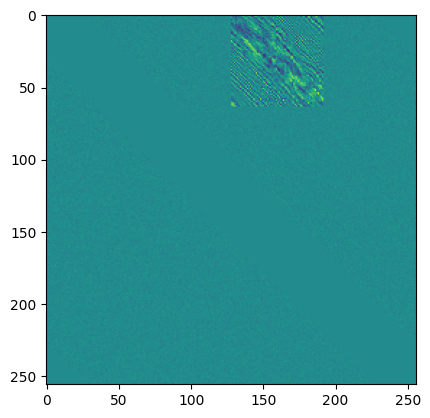

In [19]:
plt.imshow(input_5db[0,0,:,:].detach().cpu().numpy())

In [13]:
# Start DDS for Regularization:
pred_batch_after_cbs = normalize(1500 * torch.cat([initial_pred_free.unsqueeze(0).unsqueeze(0), initial_pred_10db.unsqueeze(0).unsqueeze(0), initial_pred_5db.unsqueeze(0).unsqueeze(0)], dim = 0))
x_0_ref_hat = torch.clone(pred_batch_after_cbs)

for t_value in np.linspace(0.001, 0.03, 3)[::-1]:
    with torch.no_grad():
        t = (t_value) * torch.ones(x_0_ref_hat.shape[0], device= x_0_ref_hat.device)
        t_i =  (torch.floor(t* sde.N) + 1)/sde.N

        z = torch.randn_like(x_0_ref_hat)
        mean, std, coef = sde.marginal_prob(x_0_ref_hat, t_i)
        perturbed_data = mean + std[:, None, None, None] * z
        perturbed_score = score_fn(perturbed_data, t_i)
        
        x_0_ref_hat = (perturbed_data + perturbed_score * std[:, None, None, None] ** 2)/coef
        x_0_ref_hat = (coef) * x_0_ref_hat + (1 - coef) * pred_batch_after_cbs

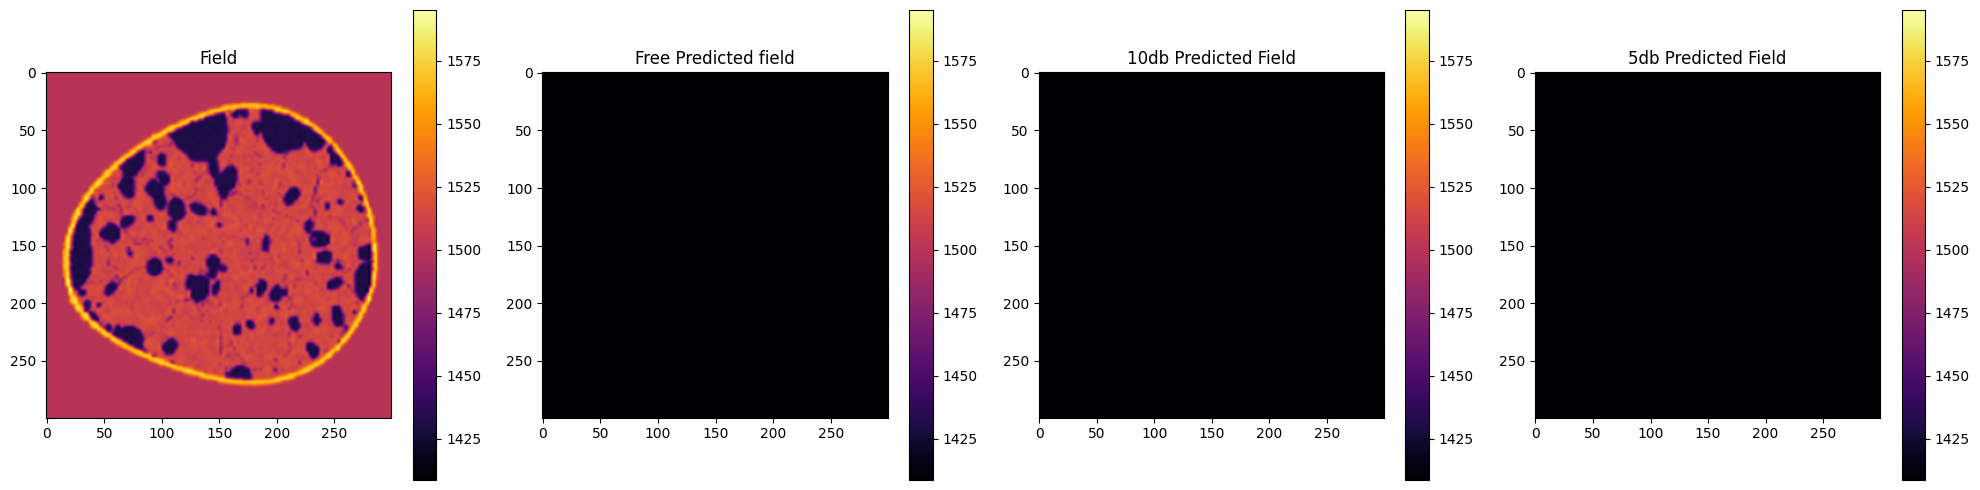

In [14]:
pred_batch_plot = denormalize(pred_batch)[:,:,90:390,90:390].detach().cpu().numpy()
output_plot = denormalize(output)[:,:,90:390,90:390].detach().cpu().numpy()

log_image("test_debug.png", output_plot, pred_batch_plot)

# 计算 PSNR
psnr_value_free = calculate_psnr(pred_batch_plot[0,0], output_plot[0,0])
psnr_value_10db = calculate_psnr(pred_batch_plot[1,0], output_plot[0,0])
psnr_value_5db = calculate_psnr(pred_batch_plot[2,0], output_plot[0,0])

# 计算 SSIM
ssim_value_free = calculate_ssim(pred_batch_plot[0,0], output_plot[0,0])
ssim_value_10db = calculate_ssim(pred_batch_plot[1,0], output_plot[0,0])
ssim_value_5db = calculate_ssim(pred_batch_plot[2,0], output_plot[0,0])

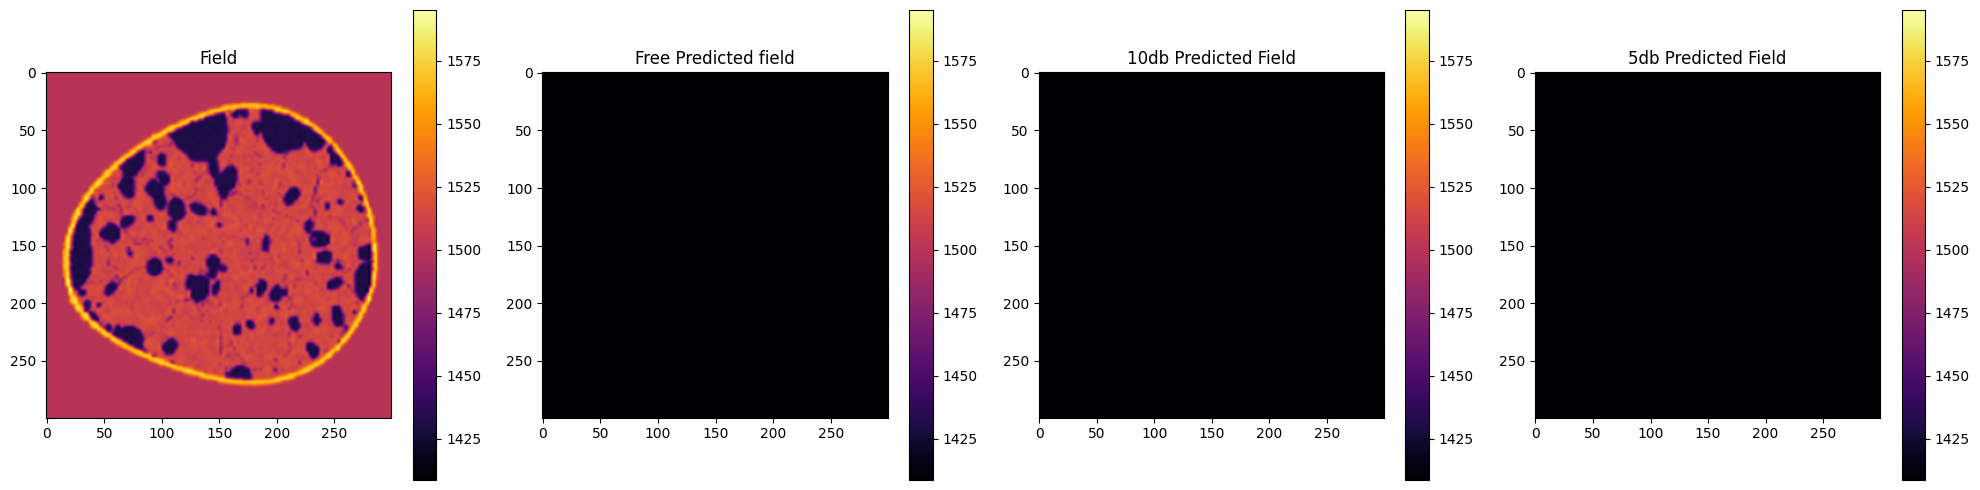

In [ ]:
pred_batch_after_cbs_plot = denormalize(x_0_ref_hat)[:,:,90:390,90:390].detach().cpu().numpy()

log_image("test_debug_after.png", output_plot, pred_batch_after_cbs_plot)

# 计算 PSNR
psnr_value_free_after = calculate_psnr(pred_batch_after_cbs_plot[0,0], output_plot[0,0])
psnr_value_10db_after = calculate_psnr(pred_batch_after_cbs_plot[1,0], output_plot[0,0])
psnr_value_5db_after = calculate_psnr(pred_batch_after_cbs_plot[2,0], output_plot[0,0])

# 计算 SSIM
ssim_value_free_after = calculate_ssim(pred_batch_after_cbs_plot[0,0], output_plot[0,0])
ssim_value_10db_after = calculate_ssim(pred_batch_after_cbs_plot[1,0], output_plot[0,0])
ssim_value_5db_after = calculate_ssim(pred_batch_after_cbs_plot[2,0], output_plot[0,0])

In [42]:
from tabulate import tabulate

# 准备数据进行对比打印
data = [
    ["Free", psnr_value_free, ssim_value_free, psnr_value_free_after, ssim_value_free_after],
    ["10dB", psnr_value_10db, ssim_value_10db, psnr_value_10db_after, ssim_value_10db_after],
    ["5dB", psnr_value_5db, ssim_value_5db, psnr_value_5db_after, ssim_value_5db_after],
]

# 表格头部
headers = ["Condition", "PSNR Before", "SSIM Before", "PSNR After", "SSIM After"]

# 使用 tabulate 打印表格
print(tabulate(data, headers=headers, tablefmt="grid"))

+-------------+---------------+---------------+--------------+--------------+
| Condition   |   PSNR Before |   SSIM Before |   PSNR After |   SSIM After |
+=============+===============+===============+==============+==============+
| Free        |       32.5703 |      0.970776 |      33.5332 |     0.976288 |
+-------------+---------------+---------------+--------------+--------------+
| 10dB        |       31.5708 |      0.963136 |      32.3858 |     0.968423 |
+-------------+---------------+---------------+--------------+--------------+
| 5dB         |       27.076  |      0.89596  |      27.3664 |     0.899858 |
+-------------+---------------+---------------+--------------+--------------+
